# Time series: motif and shaplet

## Motif discovery 
**Motif**: a repeated pattern in the time series. We can discover motif by computing the Matrix Profile: a data structure that annotates time series by using a sliding window to compare the pairwise distance among the subsequences.

### Matrix Profile
You can use these packages:
    
    
https://github.com/target/matrixprofile-ts

https://github.com/TDAmeritrade/stumpy

In [1]:
import math
import numpy as np
import pandas as pd
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.spatial.distance import pdist, squareform

from matrixprofile import *

data = './data/'

In [2]:
df = pd.read_csv(f'{data}air_passengers.csv', parse_dates=True, index_col='Month', date_format='%Y-%m')
df.head()

,#Passengers
Month,
1949-01-01,112
1949-02-01,118
1949-03-01,132
1949-04-01,129
1949-05-01,121


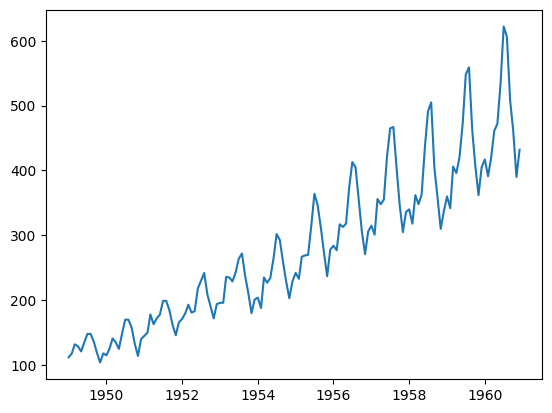

In [3]:
ts = df['#Passengers']
plt.plot(ts)
plt.show()

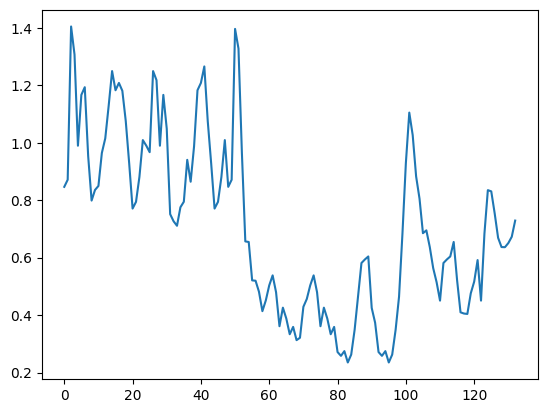

In [4]:
w = 12
mp, mpi = matrixProfile.stomp(ts.values, w)

plt.plot(mp)
plt.show()

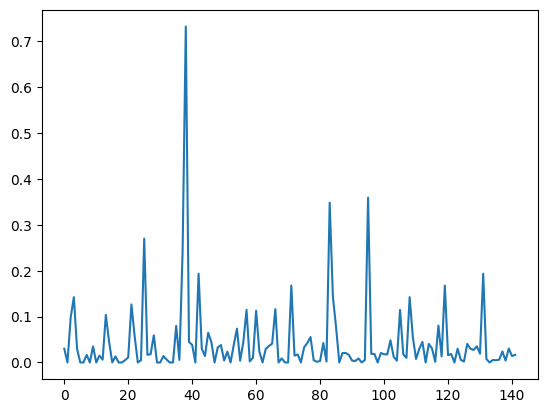

In [5]:
w = 3
mp, mpi = matrixProfile.stomp(ts.values, w)

plt.plot(mp)
plt.show()

### Motif discovery
Parameters:
- `max_motifs`: stop finding new motifs once we have max_motifs
- `radius`: For each motif found, find neighbors that are within $radius * motif_{mp}$ of the first.
- `n_neighbors`: number of neighbors from the first to find. If it is None, find all.
- `ex_zone`: minimum distance between indices for after each subsequence is identified. Defaults to m/2 where m is the subsequence length. If ex_zone = 0, only the found index is exclude, if ex_zone = 1 then if idx is found as a motif idx-1, idx, idx+1 are excluded.


The function returns a tuple (top_motifs, distances) which are lists of the same length.

- `top_motifs`: This is a list of the indices found for each motif. The first index is the nth motif followed by all nearest neighbors found sorted by distances.
- `distances`: Minimum Matrix profile value for each motif set.

In [6]:
mo, mod  = motifs.motifs(ts.values, (mp, mpi), max_motifs=5)

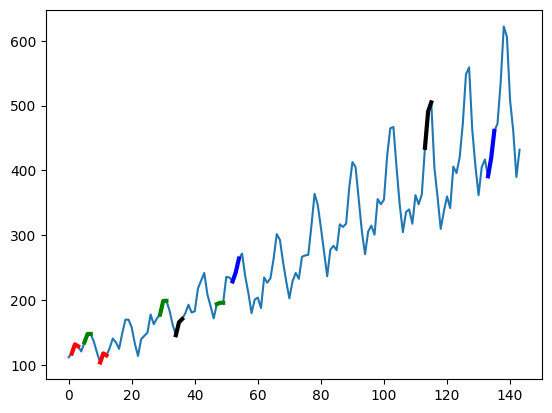

In [7]:
plt.plot(ts.values)
colors = ['r', 'g', 'k', 'b', 'y'][:len(mo)]
for m, d, c in zip(mo, mod, colors):
    for i in m:
        m_shape = ts.values[i:i+w]
        plt.plot(range(i,i+w), m_shape, color=c, lw=3)

plt.show()

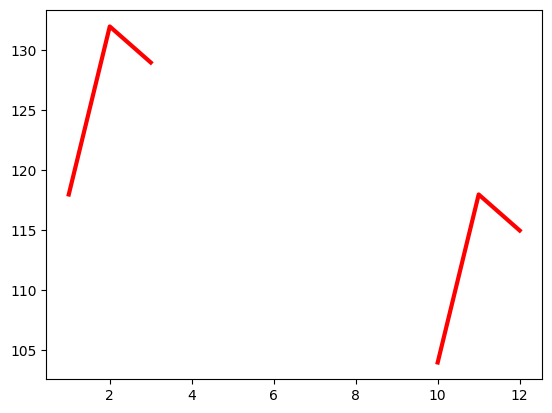

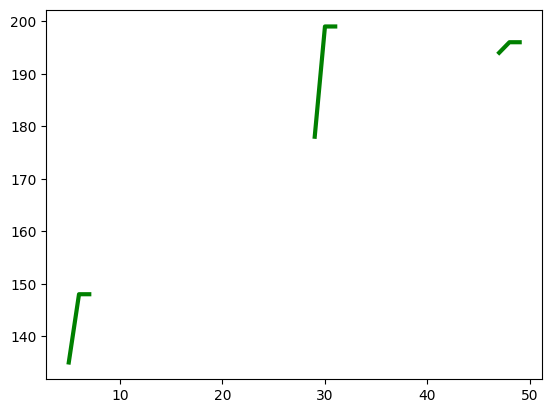

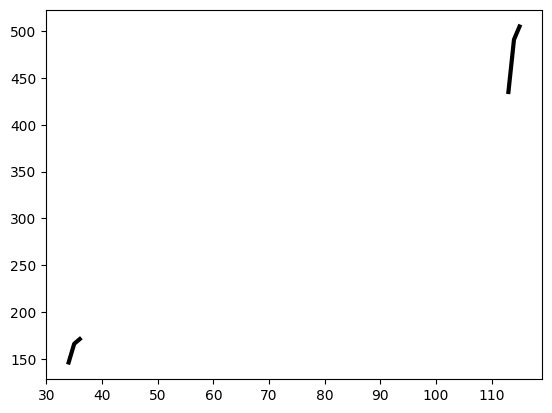

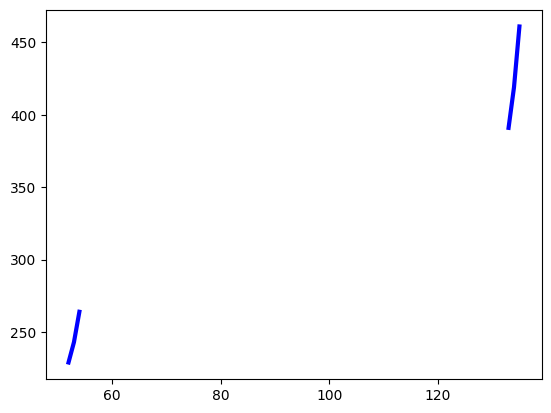

In [14]:
for m, d, c in zip(mo, mod, colors):
    for i in m:
        m_shape = ts.values[i:i+w]
        plt.plot(range(i,i+w), m_shape, color=c, lw=3)
    plt.show()

### Anomaly Discovery
Parameters:
- `mp`: matrix profile numpy array
- `k`: the number of discords to discover
- `ex_zone`: the number of samples to exclude and set to Inf on either side of a found discord   


Returns a list of indexes represent the discord starting locations. `MaxInt` indicates there were no more discords that could be found due to too many exclusions or profile being too small. Discord start indices are sorted by highest matrix profile value.

In [15]:
from matrixprofile.discords import discords
anoms = discords(mp, ex_zone=3, k=5)

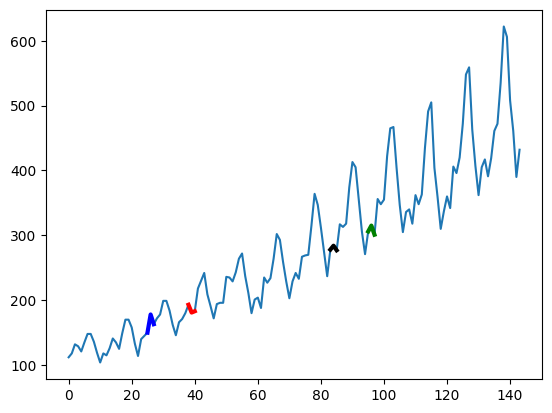

In [16]:
plt.plot(ts.values)
colors = ['r', 'g', 'k', 'b', 'y'][:len(mo)]
for a, c in zip(anoms, colors):
    a_shape = ts.values[a:a+w]
    plt.plot(range(a, a+w), a_shape, color=c, lw=3)

plt.show()

## Shaplet discovery

A **shapelet** is a **short subsequence** of a time series that is **highly discriminative** for classification.  
- Think of it as a *pattern* (a “shape”) that characterizes one class vs. another.  
- Example: In ECG data, a sharp peak may indicate arrhythmia → the subsequence containing that peak is a **shapelet**.  

Shapelets are not the full time series, but **snippets** that best separate classes.
Instead of comparing entire time series, shapelet-based methods focus on whether **specific patterns appear**.  
For each candidate shapelet $s$, compute its **distance** to every time series $T$.  


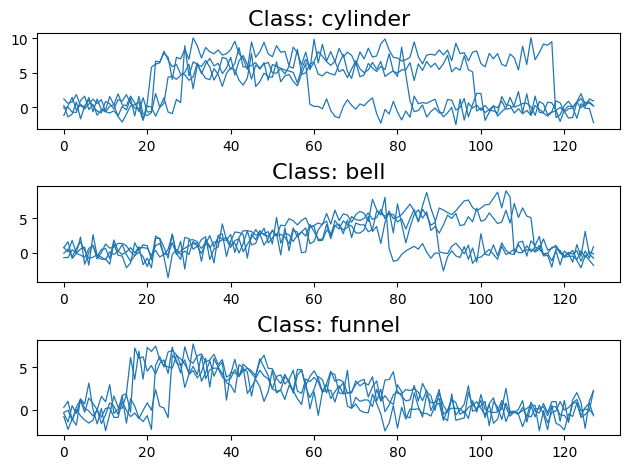

In [17]:
from pyts.datasets import make_cylinder_bell_funnel

X, y = make_cylinder_bell_funnel(n_samples=12, random_state=42)

plt.figure()
for i, classe in enumerate(['cylinder', 'bell', 'funnel']):
    plt.subplot(3, 1, i + 1)
    for x in X[y == i]:
        plt.plot(x, color='C0', linewidth=0.9)
    plt.title('Class: {}'.format(classe), fontsize=16)

plt.tight_layout()
plt.subplots_adjust(hspace=0.6)
plt.show()

In [18]:
from tensorflow.keras.optimizers import Adagrad
from tslearn.shapelets import ShapeletModel
from tslearn.shapelets import grabocka_params_to_shapelet_size_dict

from tslearn.preprocessing import TimeSeriesScalerMinMax

In [19]:
# Compute number and length of shapelets.
# l: Fraction of the length of time series to be used for base shapelet length
# r: Number of different shapelet lengths to use

# return: Dictionary giving, for each shapelet length, the number of such shapelets to be generated

In [19]:
n_ts, ts_sz = X.shape
n_classes = len(set(y))


shapelet_sizes = grabocka_params_to_shapelet_size_dict(n_ts=n_ts,
                                                       ts_sz=ts_sz,
                                                       n_classes=n_classes,
                                                       l=0.1,
                                                       r=1)

print('n_ts', n_ts)
print('ts_sz', ts_sz)
print('n_classes', n_classes)
print('shapelet_sizes', shapelet_sizes)

n_ts 12
ts_sz 128
n_classes 3
shapelet_sizes {12: 3}


In [8]:
shp_clf = ShapeletModel(n_shapelets_per_size=shapelet_sizes,
                        optimizer="sgd",
                        weight_regularizer=.01,
                        max_iter=200,
                        verbose=1)

NameError: name 'ShapeletModel' is not defined

In [21]:
shp_clf.fit(X, y)

Epoch 1/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 230ms/step - categorical_accuracy: 0.2500 - categorical_crossentropy: 2.7079 - loss: 2.7374
Epoch 2/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - categorical_accuracy: 0.1667 - categorical_crossentropy: 2.4517 - loss: 2.4808
Epoch 3/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - categorical_accuracy: 0.1667 - categorical_crossentropy: 2.3605 - loss: 2.3892
Epoch 4/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - categorical_accuracy: 0.1667 - categorical_crossentropy: 2.3230 - loss: 2.3514
Epoch 5/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - categorical_accuracy: 0.1667 - categorical_crossentropy: 2.2958 - loss: 2.3240
Epoch 6/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - categorical_accuracy: 0.1667 - categorical_crossentropy: 2.2570 - loss: 2.2848
Epoch 7/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - categorical_accuracy: 0.1667 - categorical_crossentropy: 2.2285 - loss: 2.2560
Epoch 8/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - categorical_accuracy: 0.1667 - catego

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - categorical_accuracy: 0.5000 - categorical_crossentropy: 0.8942 - loss: 0.9121
Epoch 100/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - categorical_accuracy: 0.5000 - categorical_crossentropy: 0.8901 - loss: 0.9079
Epoch 101/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - categorical_accuracy: 0.5000 - categorical_crossentropy: 0.8862 - loss: 0.9041
Epoch 102/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - categorical_accuracy: 0.5000 - categorical_crossentropy: 0.8827 - loss: 0.9005
Epoch 103/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - categorical_accuracy: 0.5000 - categorical_crossentropy: 0.8786 - loss: 0.8964
Epoch 104/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - categorical_accuracy: 0.5000 - categorical_crossentropy: 0.8747 - loss: 0.8925
Epoch 105/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - categorical_accuracy: 0.5000 - categorical_crossentropy: 0.8717 - loss: 0.8895
Epoch 106/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - categorical_accuracy: 0.5000 - catego

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - categorical_accuracy: 0.6667 - categorical_crossentropy: 0.6801 - loss: 0.6980
Epoch 198/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - categorical_accuracy: 0.6667 - categorical_crossentropy: 0.6787 - loss: 0.6966
Epoch 199/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - categorical_accuracy: 0.6667 - categorical_crossentropy: 0.6769 - loss: 0.6949
Epoch 200/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - categorical_accuracy: 0.6667 - categorical_crossentropy: 0.6756 - loss: 0.6936


LearningShapelets(max_iter=200, n_shapelets_per_size={12: 3}, verbose=1,
                  weight_regularizer=0.01)

In [23]:
from sklearn.metrics import accuracy_score
predicted_labels = shp_clf.predict(X)
print("Correct classification rate:", accuracy_score(y, predicted_labels))
predicted_locations = shp_clf.locate(X)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
Correct classification rate: 0.6666666666666666
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step


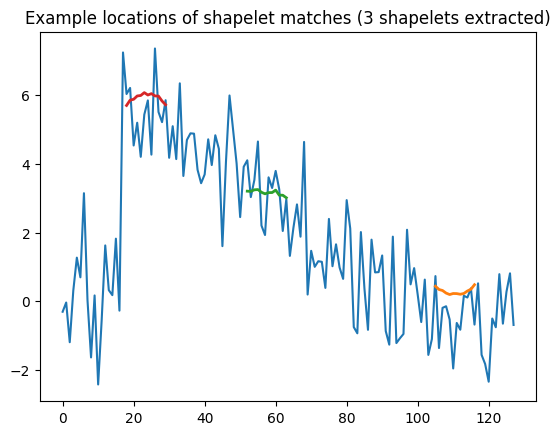

In [24]:
ts_id = 0
plt.figure()
n_shapelets = sum(shapelet_sizes.values())
plt.title(f"""Example locations of shapelet matches ({n_shapelets} shapelets extracted)""")

plt.plot(X[ts_id].ravel())
for idx_shp, shp in enumerate(shp_clf.shapelets_):
    t0 = predicted_locations[ts_id, idx_shp]
    plt.plot(np.arange(t0, t0 + len(shp)), shp, linewidth=2)

### Another way of extracting shaplets

The Shapelet Transform algorithm extracts the most discriminative shapelets from a data set of time series. A shapelet is defined as a subset of consecutive points from a time series. Two criteria are made available: mutual information and F-scores.

In [25]:
from pyts.transformation import ShapeletTransform
st = ShapeletTransform(n_shapelets=5, window_sizes=[8])
st.fit(X, y)

ShapeletTransform(n_shapelets=5, window_sizes=[8])

In [26]:
len(st.shapelets_)

5

In [27]:
st.shapelets_

array([[3.55617016, 4.45101904, 1.9655695 , 1.8797641 , 2.37903718,
        2.25854883, 2.49581638, 2.06218607],
       [3.86768091, 3.44254948, 1.97362051, 4.03209882, 4.69276688,
        2.65224013, 1.44202827, 2.40616013],
       [2.03462057, 5.26993205, 4.98310642, 1.93153851, 2.67752343,
        3.55562448, 2.71529886, 0.98846153],
       [2.98646757, 3.37317756, 3.56491409, 1.51560696, 2.71553641,
        3.37816335, 1.11274083, 3.4952731 ],
       [1.98968297, 4.36556417, 4.12494848, 1.97593873, 1.89793117,
        1.98066962, 1.99844116, 3.38858832]])

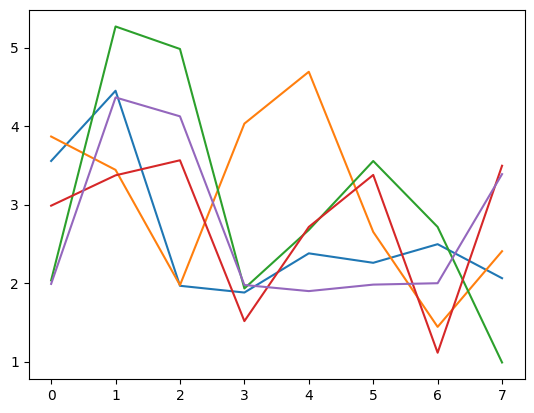

In [28]:
for s in st.shapelets_:
    plt.plot(s)

plt.show()

The indices for the corresponding shapelets in the training set. The first column consists of the indices of the samples. The second column consists of the starting indices (included) of the shapelets. The third column consists of the ending indices (excluded) of the shapelets.

In [29]:
st.indices_

array([[ 3, 78, 86],
       [11, 53, 61],
       [ 8, 41, 49],
       [ 3, 70, 78],
       [11, 63, 71]])

In [37]:
st.scores_

array([0.72282047, 0.73922258, 0.76154401, 0.77463925, 0.84408369])

## Shapelets and Time Series Classification

Once distances are computed, the problem transforms into feature-based classification:

- Each shapelet becomes a **feature** (its distance to a series).  
- If there are $k$ shapelets, each time series is represented as a $k$-dimensional vector.  
- Then, any classifier (decision tree, random forest, logistic regression, neural net, etc.) can be applied.  

Workflow:  
Raw time series $\;\to\;$ **Shapelet Transform** $\;\to\;$ Distance-based features $\;\to\;$ Classifier.

---

### Why Shapelets?
- **Interpretability**: Easy to *visualize* which subsequences are discriminative.  
- **Robustness**: Focus on local patterns, not global alignment.  
- **Efficiency**: Avoids costly methods like full Dynamic Time Warping (DTW).

---

### Shapelet-based Classifiers
- **Shapelet Tree**: Decision tree that splits on shapelet distances.  
- **Shapelet Transform + ML**: Transform data into shapelet distance features, then apply standard ML.  
- **Deep Shapelets (Learning Shapelets)**: Learn shapelets directly with gradient descent (Grabocka et al., 2014).  

---


### Deep Shapelets (Learning Shapelets)

Classic shapelet discovery relies on **searching through subsequences** of training data to find the most discriminative shapelets.  
- This is **computationally expensive** (quadratic or worse in series length).  
- Shapelets are limited to patterns **already present** in the training data.  


The idea of **Learning Shapelets** (Grabocka et al., 2014) is to **directly learn shapelets** during training using optimization, similar to how neural networks learn weights.

---

#### Core Idea
Instead of extracting subsequences, we treat shapelets as **trainable parameters**.  

- Let $\{S_1, S_2, \dots, S_m\}$ be a set of $m$ shapelets.  
- Each $S_j$ is initialized randomly (not necessarily from the dataset).  
- For a time series $T$, we compute the **distance to each shapelet**:  

$$
d(S_j, T) = \min_i \| S_j - T_{i:i+|S_j|} \|
$$

- These distances are **features** for classification.

The trick is to make this process **differentiable**, so we can use **gradient descent** to optimize shapelets jointly with a classifier.

- Instead of a hard minimum, use a **soft-min approximation** (differentiable version of $\min$).
- This allows gradients to flow back to the shapelets $S_j$.

---

#### Benefits
- **No need for exhaustive search** of subsequences.  
- **Shapelets are optimized** for the classification task.  
- **Interpretability**: Learned shapelets can still be visualized like in classic shapelet methods.  
- **Flexibility**: The number and length of shapelets are hyperparameters.  


In [36]:
from pyts.classification import LearningShapelets
shp_clf = LearningShapelets(random_state=42, tol=0.01)

In [31]:
shp_clf.fit(X, y)

LearningShapelets(random_state=42, tol=0.01)

In [32]:
accuracy = shp_clf.score(X , y)
accuracy

1.0

In [33]:
shp_clf.predict(X)

array([2, 0, 1, 2, 0, 0, 1, 0, 2, 1, 1, 2])

In [34]:
# Select three shapelets
sel_shapelets = np.asarray([shp_clf.shapelets_[0, 0], 
                        shp_clf.shapelets_[0, 1], 
                        shp_clf.shapelets_[0, 2]])

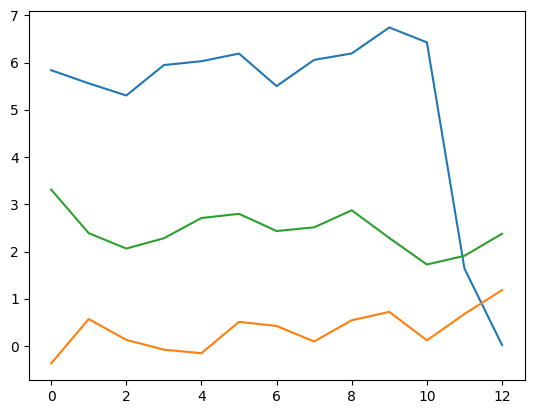

In [35]:
plt.plot(sel_shapelets[0])
plt.plot(sel_shapelets[1])
plt.plot(sel_shapelets[2])

plt.show()